# ChadGPT — 250M Parameter GPT with GQA + RoPE

Kaggle Script mode — 2× T4 GPU training via HuggingFace Accelerate

In [1]:
%pip install torch tiktoken accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 29.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 8.4 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [accelerate]5 [accelerate]_hub]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Imports

In [34]:
import os
import math
import time
from contextlib import nullcontext
import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from accelerate import Accelerator

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

## Model Config

In [35]:
GPT_CONFIG_250M = {
    "vocab_size": 50259,
    "context_length": 4096,
    "emb_dim": 1024,
    "n_heads": 16,
    "n_kv_heads": 4,
    "n_layers": 18,
    "drop_rate": 0.0,
    "qkv_bias": False,
}

## Training Config

Effective batch size = `batch_size × grad_accum_steps × num_gpus × context_length` = 2 × 64 × 2 × 1024 ≈ **262k tokens/step**

In [3]:
'''
 train config according to 5 billion dataset tokens 
 total steps  = (n_train_shards * no of tokens in 1 shard ) / effective batch size
 the model is trained on kaggle platform for their GPUs so the folder structure is according to that 
'''

TRAIN_CONFIG = {
    "shard_dir":       ".",
    "n_train_shards":  40,
    "n_val_shards":    10,
    "context_length":  1024,

    "lr":              3e-4,
    "weight_decay":    0.1,
    "betas":           (0.9, 0.95),
    "grad_clip":       1.0,

    "warmup_steps":    500,
    "max_steps":       15259,
    "min_lr_ratio":    0.1,

    "batch_size":      2,
    "grad_accum_steps": 64,

    "eval_interval":   100,
    "eval_steps":      20,
    "log_interval":    10,

    "ckpt_dir":        "/kaggle/working/checkpoints",
    "save_interval":   100,
}

## Tokenizer Helpers

In [36]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>', '<|im_start|>', '<|im_end|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

## Model Components

### LayerNorm

In [37]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

### GELU Activation

In [38]:
'''
if you want you can also use swiglu in here instead of the gelu ,
to use this in the feed forward network just chnage the entire nn.sequential to     SwiGLU(cfg["emb_dim"])

class SwiGLU(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.w1 = nn.Linear(emb_dim, 4 * emb_dim, bias=False)
        self.w2 = nn.Linear(emb_dim, 4 * emb_dim, bias=False)
        self.w3 = nn.Linear(4 * emb_dim, emb_dim, bias=False)

    def forward(self, x):
        return self.w3(F.silu(self.w1(x)) * self.w2(x))
'''
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

### FeedForward Network

In [39]:
''' 
it helps the model to expand the layers and then look at the minute details so it expands it to 4 times the embedding dimension,
but input and output dimension should be the same
'''

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

### Rotary Position Embedding (RoPE)

Applied inside each attention head to encode relative position information directly into Q and K vectors.

In [40]:
''' 
in this the theta is used to rotate the matrix for the Q and K matrices in 2d dimension to find the relative distance between them 
'''
class RoPEEmbedding(nn.Module):
    def __init__(self, emb_dim, n_heads, base=10000):
        super().__init__()
        self.head_dim = emb_dim // n_heads
        theta = 1.0 / (base ** (torch.arange(0, self.head_dim, 2).float() / self.head_dim))
        self.register_buffer("theta", theta)

    def _rotate(self, x):
        x1, x2 = x[..., ::2], x[..., 1::2]
        return torch.stack([-x2, x1], dim=-1).flatten(-2)

    def forward(self, x, start_pos=0):
        seq_len = x.shape[-2]
        t = torch.arange(start_pos, start_pos + seq_len, device=x.device).unsqueeze(1)
        freqs = (t * self.theta).unsqueeze(0).unsqueeze(0)
        cos = torch.cos(freqs).repeat_interleave(2, dim=-1)
        sin = torch.sin(freqs).repeat_interleave(2, dim=-1)
        return x * cos + self._rotate(x) * sin

### Grouped Query Attention (GQA)

Uses fewer KV heads than query heads — K and V are expanded via `repeat_interleave` to match. Includes a KV cache for autoregressive inference.

In [41]:
''' 
here is also the implementation of the kv caching where we cache the past token in K and V 
and use the generate attn score to replace the Q 
which reduces the computational power and caches the K and V and also only 1 token is generate at a time on the attn output side

in the GQA part 
group size (n_rep) is n_heads / n_kv_heads 
this is the group of heads sharing same K and V values to reduce the KV cache while still preserving the output quality 
if you increase this value by either reducing kv heads or by increaseing attn heads memory usage will decrease but the output quality will decrease and 
if you decrease this value doing vice versa the memroy usage will increase but the output quality will also increase 
'''

class GroupedQueryAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, n_heads, n_kv_heads, qkv_bias=False):
        super().__init__()
        assert n_heads % n_kv_heads == 0
        assert d_out % n_heads == 0

        self.n_heads    = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_rep      = n_heads // n_kv_heads
        self.head_dim   = d_out // n_heads

        self.W_query  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key    = nn.Linear(d_in, self.n_kv_heads * self.head_dim, bias=qkv_bias)
        self.W_value  = nn.Linear(d_in, self.n_kv_heads * self.head_dim, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)
        self.rope     = RoPEEmbedding(d_out, n_heads)

    def forward(self, x, past_kv=None, start_pos=0):
        B, T, _ = x.shape

        q = self.W_query(x).view(B, T, self.n_heads,    self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(B, T,   self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)

        q = self.rope(q, start_pos=start_pos)
        k = self.rope(k, start_pos=start_pos)

        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim=-2)
            v = torch.cat([past_v, v], dim=-2)

        new_kv = (k, v)

        k = k.repeat_interleave(self.n_rep, dim=1)
        v = v.repeat_interleave(self.n_rep, dim=1)

        out = torch.nn.functional.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.dropout.p if self.training else 0.0,
            is_causal=True if T > 1 else False,
        )

        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.out_proj(out), new_kv

### Transformer Block

In [42]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            n_heads=cfg["n_heads"],
            n_kv_heads=cfg["n_kv_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff           = FeedForward(cfg)
        self.norm1        = LayerNorm(cfg["emb_dim"])
        self.norm2        = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x, past_kv=None, start_pos=0):
        shortcut = x
        x = self.norm1(x)
        x, new_kv = self.att(x, past_kv=past_kv, start_pos=start_pos)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x, new_kv

### GPT Model

Weight-tied embedding — `out_head` shares weights with `tok_emb`. Residual projections are scaled by `1/√(2·n_layers)` for stable deep training.

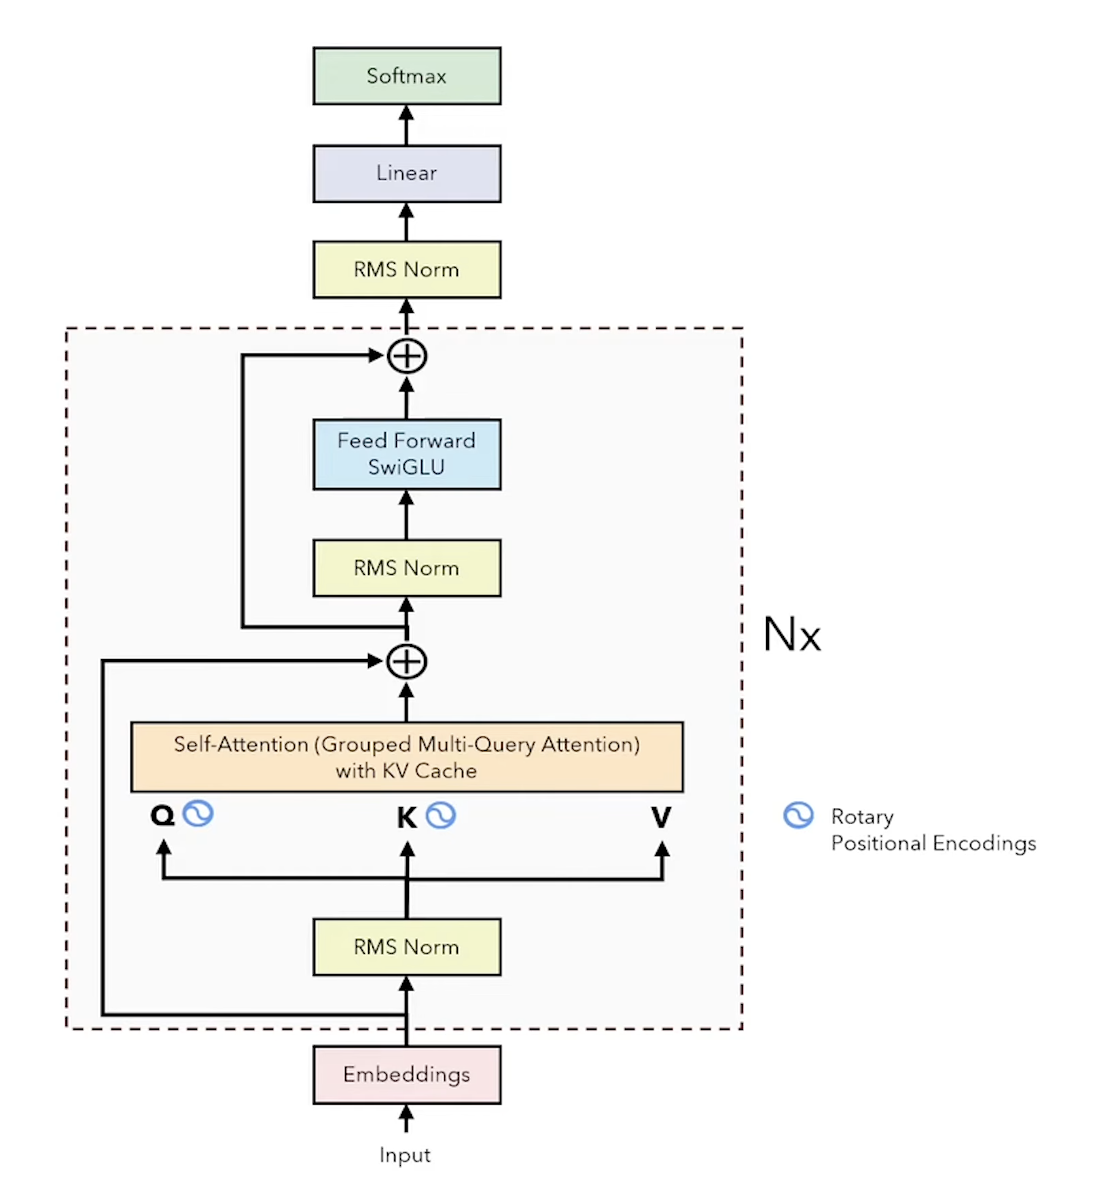

## just instead of RMS normalization it's normal layer normalization

In [43]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb   = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.drop_emb  = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.ModuleList(
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = self.tok_emb.weight

        self.apply(self._init_weights)
        for block in self.trf_blocks:
            nn.init.normal_(block.att.out_proj.weight, mean=0.0,
                            std=0.02 / math.sqrt(2 * cfg["n_layers"]))
            nn.init.normal_(block.ff.layers[2].weight, mean=0.0,
                            std=0.02 / math.sqrt(2 * cfg["n_layers"]))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, in_idx, past_key_values=None, start_pos=0):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        x = self.drop_emb(tok_embeds)

        new_key_values = []
        for i, block in enumerate(self.trf_blocks):
            layer_past = past_key_values[i] if past_key_values is not None else None
            x, layer_kv = block(x, past_kv=layer_past, start_pos=start_pos)
            new_key_values.append(layer_kv)

        x = self.final_norm(x)
        logits = x @ self.tok_emb.weight.T
        return logits, new_key_values

### Sanity Check — Parameter Count

In [44]:
model = GPTModel(GPT_CONFIG_250M)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

total_size_bytes = total_params * 4
total_size_gb = total_size_bytes / (1024 * 1024 * 1024)
print(f"Total size of the model: {total_size_gb:.2f} GB")

Total number of parameters: 249,832,448
Total size of the model: 0.93 GB


In [19]:
model.state_dict()

OrderedDict([('out_head',
              tensor([[-0.0030, -0.0208,  0.0077,  ...,  0.0220, -0.0289,  0.0100],
                      [-0.0114,  0.0017, -0.0152,  ...,  0.0163,  0.0042,  0.0145],
                      [ 0.0136, -0.0223, -0.0228,  ...,  0.0112,  0.0135, -0.0269],
                      ...,
                      [ 0.0194, -0.0138,  0.0042,  ..., -0.0024, -0.0130,  0.0250],
                      [ 0.0104,  0.0477,  0.0448,  ..., -0.0285, -0.0197,  0.0312],
                      [ 0.0035, -0.0187,  0.0065,  ...,  0.0158, -0.0002, -0.0084]])),
             ('tok_emb.weight',
              tensor([[-0.0030, -0.0208,  0.0077,  ...,  0.0220, -0.0289,  0.0100],
                      [-0.0114,  0.0017, -0.0152,  ...,  0.0163,  0.0042,  0.0145],
                      [ 0.0136, -0.0223, -0.0228,  ...,  0.0112,  0.0135, -0.0269],
                      ...,
                      [ 0.0194, -0.0138,  0.0042,  ..., -0.0024, -0.0130,  0.0250],
                      [ 0.0104,  0.0477,  0.0

## Generation with KV Cache

In [45]:
def generate(model, idx, max_new_tokens, temperature=0.0, top_k=None, top_p=None, repetition_penalty=1.0, eos_id=None):
    past_key_values = None
    start_pos = 0
    curr_idx = idx

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits, past_key_values = model(curr_idx, past_key_values=past_key_values,
                                            start_pos=start_pos)

        logits = logits[:, -1, :]

        if repetition_penalty != 1.0:
            for token_id in set(idx[0].tolist()):
                if logits[0, token_id] > 0:
                    logits[0, token_id] /= repetition_penalty
                else:
                    logits[0, token_id] *= repetition_penalty

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1:]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf"), device=logits.device),
                logits,
            )

        if top_p is not None and top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0
            indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
            logits[indices_to_remove] = float("-inf")

        if temperature > 0.0:
            logits = logits / temperature
            probs  = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and (idx_next == eos_id).any():
            break

        idx       = torch.cat((idx, idx_next), dim=1)
        start_pos += curr_idx.shape[1]
        curr_idx  = idx_next

    return idx

### Quick Generation Test (Untrained)

In [46]:
def get_chatml_tokenizer():
    """
    Returns a tiktoken GPT-2 encoding extended with ChatML special tokens.
    <|im_start|> = 50257, <|im_end|> = 50258 (matches SFT training/prepare_openhermes_sft.py)
    """
    base = tiktoken.get_encoding("gpt2")
    tokenizer = tiktoken.Encoding(
        name="gpt2_chatml",
        pat_str=base._pat_str,
        mergeable_ranks=base._mergeable_ranks,
        special_tokens={
            **base._special_tokens,
            "<|im_start|>": 50257,
            "<|im_end|>": 50258,
        },
    )
    return tokenizer

In [14]:
torch.manual_seed(123)
tokenizer = get_chatml_tokenizer()
token_ids = generate(
    model=model,
    idx=text_to_token_ids("hellow how are you ?", tokenizer),
    max_new_tokens=25,
    top_k=25,
    temperature=1.4,
    eos_id=50256
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 hellow how are you ? giveyes Casting Casting 840 Sandwich franchisesPLIED photograpSus Draw remem revel Hyder cluelessLA Serious cluelessLA clueless liquidity EuclLAriptMult


## Dataset & Data Loading

Chunks are non-overlapping (stride = context_length). Degenerate chunks where >50% of tokens are identical are replaced with a safe no-op batch to prevent gradient spikes.

In [8]:
class ShardDataset(Dataset):
    def __init__(self, shard_paths: list[str], context_length: int):
        super().__init__()
        self.context_length = context_length
        self.mmaps          = []
        self.shard_lengths  = []

        for p in shard_paths:
            mm = np.memmap(p, dtype=np.uint16, mode='r')
            self.mmaps.append(mm)
            self.shard_lengths.append(len(mm))

        self.stride = context_length
        stride_lengths = [l // self.stride for l in self.shard_lengths]
        self.cumulative = np.cumsum([0] + stride_lengths)
        total_tokens = sum(self.shard_lengths)
        total_chunks = self.cumulative[-1]
        print(f"  {len(shard_paths)} shard(s) → {total_tokens:,} tokens "
              f"| {total_chunks:,} non-overlapping chunks (stride={self.stride})")

    def __len__(self):
        return int(self.cumulative[-1])

    def __getitem__(self, idx):
        shard_idx = np.searchsorted(self.cumulative[1:], idx, side='right')
        local_chunk = idx - self.cumulative[shard_idx]
        local_idx   = local_chunk * self.stride

        end = local_idx + self.context_length + 1
        if end <= self.shard_lengths[shard_idx]:
            chunk = self.mmaps[shard_idx][local_idx:end]
        else:
            part1    = self.mmaps[shard_idx][local_idx:]
            overflow = end - self.shard_lengths[shard_idx]
            if shard_idx + 1 < len(self.mmaps):
                part2 = self.mmaps[shard_idx + 1][:overflow]
                chunk = np.concatenate([part1, part2])
            else:
                chunk = np.pad(part1, (0, overflow), constant_values=0)

        chunk = chunk.astype(np.int64)

        counts = np.bincount(chunk, minlength=50257)
        if counts.max() > len(chunk) * 0.5:
            x = torch.zeros(self.context_length, dtype=torch.long)
            y = torch.full((self.context_length,), 50256, dtype=torch.long)
            return x, y

        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:],  dtype=torch.long)
        return x, y


def get_shard_paths(shard_dir, start, count):
    paths = []
    for i in range(start, start + count):
        p = os.path.join(shard_dir, f"slm_train_shard_{i}.npy")
        if not os.path.exists(p):
            raise FileNotFoundError(f"Shard not found: {p}")
        paths.append(p)
    return paths

## LR Schedule

Cosine decay with linear warmup.

In [7]:
def get_lr(step, cfg):
    warmup    = cfg["warmup_steps"]
    max_steps = cfg["max_steps"]
    lr        = cfg["lr"]
    min_lr    = lr * cfg["min_lr_ratio"]

    if step < warmup:
        return lr * (step + 1) / warmup
    if step >= max_steps:
        return min_lr
    progress = (step - warmup) / (max_steps - warmup)
    return min_lr + 0.5 * (lr - min_lr) * (1 + math.cos(math.pi * progress))

## Evaluation & Sampling

`evaluate` uses a raw (non-accelerated) DataLoader to avoid DDP rank mismatch issues. Device placement is handled manually.

In [6]:
@torch.no_grad()
def evaluate(model, val_loader, cfg):
    model.eval()
    model_device = next(model.parameters()).device
    losses = []
    for i, (x, y) in enumerate(val_loader):
        if i >= cfg["eval_steps"]:
            break
        x, y = x.to(model_device), y.to(model_device)
        logits, _ = model(x)
        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=50256
        )
        losses.append(loss.item())
    model.train()
    avg = sum(losses) / len(losses)
    return avg, math.exp(avg)


def sample(model, tokenizer, device, prompt="The model learns"):
    model.eval()
    with torch.no_grad():
        ids = text_to_token_ids(prompt, tokenizer).to(device)
        out = generate(model, ids, max_new_tokens=30, temperature=0.8, top_k=40)
    model.train()
    return token_ids_to_text(out, tokenizer)

## Training Loop

Multi-GPU via HuggingFace Accelerate. Gradient accumulation and `no_sync` are handled manually. A separate raw `eval_loader` is used for validation to avoid DDP issues.

In [ ]:
''' 
this training loops is designed to work on the kaggle 2x T4 GPUs where it uses the 40 training shards each of 100 million tokens and 10 eval shards
and for checkpoints in the checkpoints/ directory to save the 2 models checkpoints 

to run it properly copy all the code till the entry point and paste them in 1 single cell of the kaggle notebook one after another 
add line : %%writefile chadgpt.py
to the top of the call this should be the file line 
and then in the console run the command
!accelerate launch --multi_gpu --num_processes=2 --mixed_precision=fp16 /kaggle/working/chadgpt.py

after selecting 2 T4 gpus and setting the internet toggle to on and also persistant storage to files only 

first paste the dataset creation code in another cell and run that then run this command 
'''
def train(cfg):
    accelerator = Accelerator(mixed_precision="fp16")
    device      = accelerator.device

    accelerator.print(f"Using {accelerator.num_processes} GPU(s) — device: {device}")
    os.makedirs(cfg["ckpt_dir"], exist_ok=True)

    model = GPTModel(GPT_CONFIG_250M)
    total_params = sum(p.numel() for p in model.parameters())
    accelerator.print(f"Total parameters: {total_params:,}")

    decay_params    = [p for n, p in model.named_parameters() if p.dim() >= 2]
    no_decay_params = [p for n, p in model.named_parameters() if p.dim() < 2]
    optimizer = torch.optim.AdamW([
        {"params": decay_params,    "weight_decay": cfg["weight_decay"]},
        {"params": no_decay_params, "weight_decay": 0.0},
    ], lr=cfg["lr"], betas=cfg["betas"])

    train_paths = get_shard_paths(cfg["shard_dir"], 0,                   cfg["n_train_shards"])
    val_paths   = get_shard_paths(cfg["shard_dir"], cfg["n_train_shards"], cfg["n_val_shards"])

    accelerator.print("Train shards:")
    train_ds = ShardDataset(train_paths, cfg["context_length"])
    accelerator.print("Val shards:")
    val_ds   = ShardDataset(val_paths,   cfg["context_length"])

    train_loader = DataLoader(
        train_ds, batch_size=cfg["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True, drop_last=True,
    )
    eval_loader = DataLoader(
        val_ds, batch_size=cfg["batch_size"],
        shuffle=False, num_workers=0, pin_memory=False, drop_last=True,
    )

    model, optimizer, train_loader, val_loader = accelerator.prepare(
        model, optimizer, train_loader, val_loader
    )

    tokenizer            = tiktoken.get_encoding("gpt2")
    train_iter           = iter(train_loader)
    step, tokens_seen    = 0, 0
    grad_accum           = cfg["grad_accum_steps"]
    t0                   = time.time()
    tokens_this_interval = 0
    model.train()

    resume_path = os.path.join(cfg["ckpt_dir"], "latest.pt")
    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=device)
        accelerator.unwrap_model(model).load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        step        = ckpt["step"]
        tokens_seen = ckpt.get("tokens_seen", 0)
        accelerator.print(f"Resumed from step {step}")
    else:
        accelerator.print("Starting fresh run")

    while step < cfg["max_steps"]:
        lr = get_lr(step, cfg)
        for group in optimizer.param_groups:
            group["lr"] = lr

        optimizer.zero_grad(set_to_none=True)
        accum_loss = 0.0

        for micro_step in range(grad_accum):
            try:
                x, y = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                x, y = next(train_iter)

            toks                  = x.numel() * accelerator.num_processes
            tokens_seen          += toks
            tokens_this_interval += toks
            is_last_micro         = (micro_step == grad_accum - 1)

            sync_context = accelerator.no_sync(model) if not is_last_micro else nullcontext()
            with sync_context:
                logits, _ = model(x)
                loss = nn.functional.cross_entropy(
                    logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=50256
                )
                scaled_loss = loss / grad_accum
                accelerator.backward(scaled_loss)

            loss_reduced = accelerator.reduce(loss.detach().clone(), reduction="mean")
            accum_loss  += loss_reduced.item() / grad_accum

        accelerator.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
        optimizer.step()
        step += 1

        if accelerator.is_main_process:
            if step % cfg["log_interval"] == 0:
                elapsed     = time.time() - t0
                tok_per_sec = tokens_this_interval / elapsed if elapsed > 0 else 0
                print(
                    f"step {step:>5} | loss {accum_loss:.4f} | "
                    f"ppl {math.exp(min(accum_loss, 20)):.1f} | lr {lr:.2e} | "
                    f"tok/s {tok_per_sec:,.0f} | tokens {tokens_seen/1e9:.3f}B",
                    flush=True,
                )
                t0                   = time.time()
                tokens_this_interval = 0

            if step % cfg["eval_interval"] == 0:
                raw_model = accelerator.unwrap_model(model)
                val_loss, val_ppl = evaluate(raw_model, eval_loader, cfg)
                print(f"\n[EVAL @ step {step}] val_loss={val_loss:.4f}  val_ppl={val_ppl:.2f}")
                print(f"[SAMPLE] {sample(raw_model, tokenizer, device)}\n", flush=True)
                t0                   = time.time()
                tokens_this_interval = 0

            if step % cfg["save_interval"] == 0:
                raw_model = accelerator.unwrap_model(model)
                ckpt = {
                    "step":        step,
                    "tokens_seen": tokens_seen,
                    "model":       raw_model.state_dict(),
                    "optimizer":   optimizer.state_dict(),
                    "train_cfg":   cfg,
                    "model_cfg":   GPT_CONFIG_250M,
                }
                torch.save(ckpt, os.path.join(cfg["ckpt_dir"], "latest.pt"))
                torch.save(ckpt, os.path.join(cfg["ckpt_dir"], "checkpoint.pt"))
                print(f"  → Saved checkpoint at step {step}", flush=True)

    accelerator.wait_for_everyone()
    accelerator.print("Done.")

## Entry Point

In [ ]:
if __name__ == "__main__":
    train(TRAIN_CONFIG)

## Dataset Creation

Downloads and tokenizes data into 50 shards (40 train + 10 val) of 100M tokens each using GPT-2 BPE.

In [ ]:
import os
import numpy as np
import tiktoken
from datasets import load_dataset, interleave_datasets

SHARD_DIR        = "/kaggle/working"
SHARD_SIZE       = 100_000_000
N_TRAIN_SHARDS   = 40
N_VAL_SHARDS     = 10
EOS_TOKEN        = 50256

DATASETS = [
    {
        "name":       "HuggingFaceTB/smollm-corpus",
        "config":     "cosmopedia-v2",
        "split":      "train",
        "text_field": "text",
        "weight":     1.0,
    },
]

os.makedirs(SHARD_DIR, exist_ok=True)
tokenizer = tiktoken.get_encoding("gpt2")


def tokenize(text: str) -> list[int]:
    tokens = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    tokens.append(EOS_TOKEN)
    return tokens


def save_shard(tokens: list[int], shard_index: int):
    path = os.path.join(SHARD_DIR, f"slm_train_shard_{shard_index}.npy")
    arr  = np.array(tokens[:SHARD_SIZE], dtype=np.uint16)
    np.save(path, arr)
    kind = "TRAIN" if shard_index < N_TRAIN_SHARDS else "VAL"
    print(f"  [{kind}] saved slm_train_shard_{shard_index}.npy  ({len(arr):,} tokens)", flush=True)


print("Loading datasets (streaming)...")
raw_datasets = []
weights      = []

for ds_cfg in DATASETS:
    ds = load_dataset(
        ds_cfg["name"],
        ds_cfg["config"],
        split=ds_cfg["split"],
        streaming=True,
        trust_remote_code=True,
    )
    if ds_cfg["text_field"] != "text":
        ds = ds.rename_column(ds_cfg["text_field"], "text")
    ds = ds.select_columns(["text"])

    raw_datasets.append(ds)
    weights.append(ds_cfg["weight"])
    print(f"  loaded: {ds_cfg['name']} / {ds_cfg['config']}  (text_field='{ds_cfg['text_field']}')")

mixed = interleave_datasets(
    raw_datasets,
    probabilities=weights,
    seed=42,
    stopping_strategy="first_exhausted",
).shuffle(buffer_size=10_000, seed=42)

total_shards = N_TRAIN_SHARDS + N_VAL_SHARDS
print(f"\nTokenizing → {total_shards} shards × {SHARD_SIZE:,} tokens")
print(f"  Train: shards 0–{N_TRAIN_SHARDS-1}  ({SHARD_SIZE*N_TRAIN_SHARDS/1e9:.1f}B tokens)")
print(f"  Val:   shards {N_TRAIN_SHARDS}–{total_shards-1}  ({SHARD_SIZE*N_VAL_SHARDS/1e9:.1f}B tokens)\n")

buffer      = []
shard_index = 0

for doc in mixed:
    text = doc["text"].strip()
    if not text:
        continue

    buffer.extend(tokenize(text))

    while len(buffer) >= SHARD_SIZE:
        if shard_index >= total_shards:
            break
        save_shard(buffer, shard_index)
        buffer      = buffer[SHARD_SIZE:]
        shard_index += 1

    if shard_index >= total_shards:
        break

if buffer and shard_index < total_shards:
    save_shard(buffer, shard_index)
    shard_index += 1

print(f"\nDone.")
print(f"  Total shards saved : {shard_index}")
print(f"  Files in {SHARD_DIR}:")
for f in sorted(os.listdir(SHARD_DIR)):
    if f.endswith(".npy"):
        size_mb = os.path.getsize(os.path.join(SHARD_DIR, f)) / 1e6
        print(f"    {f}  ({size_mb:.0f} MB)")

## Instruction-Tuned Model (SFT) — Inference

Load the final SFT checkpoint (`../models/sft_latest.pt`) and generate responses in ChatML format.
The user only needs to provide a plain-text prompt — the `<|im_start|>` / `<|im_end|>` framing is added automatically.

In [47]:
# ── Load the instruction-tuned (SFT) model ──
_ROPE_PI_SCALE = 1.0
def enable_position_aware_rope(pi_scale=1.0):
    global _ROPE_PI_SCALE
    _ROPE_PI_SCALE = pi_scale

def _pi_scaled_rope_forward(self, x, start_pos=0):
    seq_len = x.shape[-2]
    t = torch.arange(start_pos, start_pos + seq_len, device=x.device).unsqueeze(1).float() * _ROPE_PI_SCALE
    freqs = (t * self.theta).unsqueeze(0).unsqueeze(0)
    cos = torch.cos(freqs).repeat_interleave(2, dim=-1).to(dtype=x.dtype)
    sin = torch.sin(freqs).repeat_interleave(2, dim=-1).to(dtype=x.dtype)
    return x * cos + self._rotate(x) * sin

RoPEEmbedding.forward = _pi_scaled_rope_forward
enable_position_aware_rope(pi_scale=0.25)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

ckpt_path = "../models/latest.pt"

print("Loading SFT checkpoint...")
ckpt = torch.load(ckpt_path, map_location=device)

# Handle both raw state_dict (e.g. latest.pt) and full checkpoint dictionaries (e.g. sft_latest.pt)
if isinstance(ckpt, dict) and "model" in ckpt:
    state_dict = ckpt["model"]
    model_cfg = ckpt.get("model_cfg", None)
    info_str = f"phase: {ckpt.get('phase')}, step: {ckpt.get('step')}, tokens seen: {ckpt.get('tokens_seen', 0)/1e9:.2f}B"
else:
    state_dict = ckpt
    model_cfg = None
    info_str = "half-precision weights (state_dict)"

if model_cfg is None:
    vocab_size = state_dict["tok_emb.weight"].shape[0] if "tok_emb.weight" in state_dict else 50259
    model_cfg = dict(GPT_CONFIG_250M)
    model_cfg["vocab_size"] = vocab_size
    model_cfg["context_length"] = 4096

model = GPTModel(model_cfg)

# Set half-precision if weights are float16
first_param = next(iter(state_dict.values()))
if first_param.dtype == torch.float16:
    model.half()

model.load_state_dict(state_dict)
model.to(device)
model.eval()

# Use the ChatML-extended tokenizer (includes <|im_start|> and <|im_end|>)
tokenizer = get_chatml_tokenizer()

# Special token IDs
IM_START_ID = 50257
IM_END_ID   = 50258

print(f"SFT model loaded — {info_str}")
print(f"Vocab size: {model_cfg['vocab_size']}, Context length: {model_cfg['context_length']}")


Using device: mps
Loading SFT checkpoint...
SFT model loaded — half-precision weights (state_dict)
Vocab size: 50259, Context length: 4096


In [48]:
def chat(prompt, max_new_tokens=1024, temperature=0.8, top_k=90, top_p=0.9, repetition_penalty=1.15,
         system_prompt="You are a helpful assistant."):
    """
    Send a prompt to the instruction-tuned ChadGPT model.
    The ChatML framing (<|im_start|>/<|im_end|>) is added automatically —
    just pass your plain-text question or instruction.
    """
    # Build the ChatML-formatted input
    chat_input = (
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
        f"<|im_start|>user\n{prompt}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    input_ids = text_to_token_ids(chat_input, tokenizer).to(device)

    with torch.no_grad():
        output_ids = generate(
            model=model,
            idx=input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            eos_id=IM_END_ID,   # stop when the model emits <|im_end|>
        )

    # Decode everything, then extract only the assistant's reply
    full_text = token_ids_to_text(output_ids, tokenizer)
    # Split on the last 'assistant\n' marker to isolate the response
    marker = "<|im_start|>assistant\n"
    if marker in full_text:
        response = full_text.split(marker)[-1]
    else:
        response = full_text

    # Strip any trailing <|im_end|> or whitespace
    response = response.replace("<|im_end|>", "").strip()
    return response

In [49]:
# ── Example: just provide your prompt, ChatML tokens are handled for you ──
prompt = "Write a Python function that checks if a string is a palindrome."

print(f"Prompt: {prompt}")
print("-" * 50)
response = chat(prompt)
print(response)
print("-" * 50)

Prompt: Write a Python function that checks if a string is a palindrome.
--------------------------------------------------
def check_strings(string):
    if len(string) < str:
        return False
    print('The string is (str) out of the array')
```

To use this function, you need to create a list called `string`. It should contain all possible characters from `bool`, which will be printed as well. The code uses the `System()` class from the `snsolver` module. By creating an empty numpy list called `list`, we can then iterate over each character in `string`. Finally, the code defines two lists: `count` and `x` for sorting the input strings. The sorted list `[1]` indicates that the input strings have more than one `len` elements. The `find_strings()` function checks if any of these letters are missing from the original list. If they are not, it means there are no numbers where the first character in `string` is equal to the previous element, so you cannot assign it to `x` using the `*

In [ ]:
# ── Try different prompts — the model will respond as an instruction-following assistant ──
prompts = [
    "Explain what a neural network is in simple terms.",
    "What is the difference between a list and a tuple in Python?",
    "A recipe for chocolate chip cookies requires",
]

for p in prompts:
    print(f"\n{'='*60}")
    print(f"User: {p}")
    print(f"{'='*60}")
    print(f"Assistant: {chat(p, max_new_tokens=256)}")

In [ ]:
# ── Streaming token-by-token generation (shows tokens as they are produced) ──
prompt = "The numpy library"
system_prompt = "You are a helpful assistant."
max_new_tokens = 1024
temperature = 0.8
top_k = 90

chat_input = (
    f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
    f"<|im_start|>user\n{prompt}<|im_end|>\n"
    f"<|im_start|>assistant\n"
)

print(f"User: {prompt}")
print("-" * 50)
print("Assistant: ", end="", flush=True)

idx = text_to_token_ids(chat_input, tokenizer).to(device)

with torch.no_grad():
    past_key_values = None
    start_pos = 0
    curr_idx = idx

    for _ in range(max_new_tokens):
        logits, past_key_values = model(curr_idx, past_key_values=past_key_values,
                                        start_pos=start_pos)
        logits = logits[:, -1, :]

        top_logits, _ = torch.topk(logits, top_k)
        logits = torch.where(logits < top_logits[:, -1:], torch.tensor(float('-inf'), device=device, dtype=logits.dtype), logits)

        logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)

        # Stop on <|im_end|>
        if idx_next.item() == IM_END_ID:
            break

        start_pos += curr_idx.shape[1]
        curr_idx = idx_next
        idx = torch.cat((idx, idx_next), dim=1)
        print(tokenizer.decode([idx_next.item()]), end="", flush=True)

print("\n" + "-" * 50)
